In [8]:
import pandas as pd

df = pd.read_stata(r"Initial code\stata_data\data_regressions_passthrough.dta")

df

,year,month,day,hour,mg_price,eprice,coal,gas,brent,totalcost,...,yb,yq,totalcost2_peak,totalcost2_off,ltotalcost2_peak,ltotalcost2_off,ecost2_peak,ecost2_off,lecost2_peak,lecost2_off
0,2004.0,1.0,1.0,1,28.99,0.00,0.6668,1.3055,1.7566,NaN,...,1.0,1.0,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,2004.0,1.0,1.0,2,28.23,0.00,0.6668,1.3055,1.7566,NaN,...,1.0,1.0,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
2,2004.0,1.0,1.0,3,25.48,0.00,0.6668,1.3055,1.7566,NaN,...,1.0,1.0,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,2004.0,1.0,1.0,4,23.00,0.00,0.6668,1.3055,1.7566,NaN,...,1.0,1.0,0.000000,19.813829,0.000000,3.035618,0.000000,0.000000,0.000000,0.000000
4,2004.0,1.0,1.0,5,16.54,0.00,0.6668,1.3055,1.7566,20.158566,...,1.0,1.0,0.000000,20.158566,0.000000,3.052045,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30643,2007.0,6.0,30.0,20,31.60,0.14,0.7288,1.4082,4.0270,27.316673,...,21.0,14.0,27.316673,0.000000,3.343451,0.000000,0.051533,0.000000,0.050249,0.000000
30644,2007.0,6.0,30.0,21,31.62,0.14,0.7288,1.4082,4.0270,24.073147,...,21.0,14.0,0.000000,24.073147,0.000000,3.221797,0.000000,0.144442,0.000000,0.134917
30645,2007.0,6.0,30.0,22,35.00,0.14,0.7288,1.4082,4.0270,26.988102,...,21.0,14.0,0.000000,26.988102,0.000000,3.331779,0.000000,0.049664,0.000000,0.048470
30646,2007.0,6.0,30.0,23,40.07,0.14,0.7288,1.4082,4.0270,27.313765,...,21.0,14.0,0.000000,27.313765,0.000000,3.343348,0.000000,0.048624,0.000000,0.047479


In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ==========================================
# 1. Data Loading & Preprocessing
# ==========================================

def load_and_process_data(file_path):
    # print(f"Loading data from {file_path}...")
    df = pd.read_stata(file_path)

    # Filter Data: Use 2005-2006 for Training, 2007 for Testing
    # We filter early to avoid processing irrelevant years (e.g., 2004)
    # df = df[df['year'].isin([2005, 2006, 2007])].copy()
    
    # Handle Missing Values
    # 'ecost_int' (Emissions Cost) has some missing values in 2005. 
    # We use forward fill to maintain time-series continuity.
    df['ecost_int'] = df['ecost_int'].fillna(method='ffill').fillna(method='bfill')

    # Construct Datetime Index
    # 'hour' in the dataset is likely 1-24. We convert to 0-23 for pandas compatibility.
    df['hour_idx'] = df['hour'] - 1 
    df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) + pd.to_timedelta(df['hour_idx'], unit='h')
    df.set_index('date', inplace=True)
    df.sort_index(inplace=True)

    # --- Feature Selection ---
    # Target: 
    #   - mg_price: Market Clearing Price (MCP)
    
    # Marginal Costs:
    #   - coal, gas, brent: Marginal input costs (fuel prices)
    #   - ecost_int: Marginal emissions costs (Permit Price * Emissions Rate)
    
    # Demand & Supply Factors:
    #   - rd: Hourly Demand (Residual Demand)
    #   - windx: Wind Speed
    #   - windx2: Wind Speed Squared (Non-linear effect)
    #   - temp: Temperature
    #   - tempx: Maximum Daily Temperature
    
    # Temporal Features (for Seasonality):
    #   - hour, month, weekd (Day of Week)
    
    feature_cols = [
        'coal', 'gas', 'brent', 'ecost_int', 
        'rd', 'windx', 'windx2', 'temp', 'tempx',
        'hour', 'month', 'weekd'
    ]
    target_col = 'mg_price'
    
    return df, feature_cols, target_col

# Load data
file_name = r"Initial code\stata_data\data_regressions_passthrough.dta"
data, feature_cols, target_col = load_and_process_data(file_name)

print(f"Data range: {data.index.min()} to {data.index.max()}")
print(f"Total observations: {len(data)}")

Data range: 2004-01-01 00:00:00 to 2007-06-30 23:00:00
Total observations: 30648


C:\Users\julie\AppData\Local\Temp\ipykernel_66108\4230582155.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ecost_int'] = df['ecost_int'].fillna(method='ffill').fillna(method='bfill')


In [23]:
# ==========================================
# 2. Feature Engineering
# ==========================================

# 2.1 Cyclical Encoding for Time Features
# Encodes hour (0-23) and month (1-12) into sin/cos components to preserve cyclical continuity.
data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

# 2.2 One-Hot Encoding for Day of Week
# Capture weekend/weekday effects (weekd is typically 1-7)
dow_dummies = pd.get_dummies(data['weekd'], prefix='dow')
data = pd.concat([data, dow_dummies], axis=1)

# Update feature list to include new engineering features and remove raw categorical ones
processed_features = [
    'coal', 'gas', 'brent', 'ecost_int', 
    'rd', 'windx', 'windx2', 'temp', 'tempx',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
] + list(dow_dummies.columns)

print(f"Final Feature Set ({len(processed_features)} features): {processed_features}")

Final Feature Set (20 features): ['coal', 'gas', 'brent', 'ecost_int', 'rd', 'windx', 'windx2', 'temp', 'tempx', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6', 'dow_7']


In [24]:
# ==========================================
# 3. Train/Test Split & Scaling
# ==========================================

# train_df = data[data['year'].isin([2005, 2006])]
# test_df = data[data['year'] == 2007]

train_df = data.iloc[8784:23376, :]
val_df = data.iloc[23376:26304, :]
test_df = data.iloc[26304:26304+336, :]

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples: {len(test_df)}")

# Scaling (MinMax is standard for LSTM inputs to normalize range 0-1)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Fit scaler ONLY on training data to avoid data leakage
X_train_scaled = scaler_X.fit_transform(train_df[processed_features])
y_train_scaled = scaler_y.fit_transform(train_df[[target_col]])

X_val_scaled = scaler_X.transform(val_df[processed_features])
y_val_scaled = scaler_y.transform(val_df[[target_col]])

X_test_scaled = scaler_X.transform(test_df[processed_features])
y_test_scaled = scaler_y.transform(test_df[[target_col]])

Training samples: 14592
Validation samples: 2928
Testing samples: 336


In [25]:
# ==========================================
# 4. Sequence Generation (Windowing)
# ==========================================

# Window size: 24 hours (Look back at the past 24 hours to predict the next hour)
WINDOW_SIZE = 24

def create_sequences(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)
x_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, WINDOW_SIZE)


print(f"Input Sequence Shape: {X_train_seq.shape}") # (Samples, TimeSteps, Features)

Input Sequence Shape: (14568, 24, 20)


In [26]:
# ==========================================
# 5. LSTM Model Definition
# ==========================================

model = Sequential()

# Layer 1: LSTM with return_sequences=True
# Captures temporal dependencies over the 24-hour window
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dropout(0.2)) # Regularization

# Layer 2: Second LSTM Layer
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3: Output Layer
# Predicts a single continuous value (MCP)
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

c:\Users\julie\anaconda3\envs\coursera\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,209 (133.63 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# ==========================================
# 6. Training
# ==========================================

print("Starting training...")
# history = model.fit(
#     X_train_seq, y_train_seq,
#     epochs=100,            # You may increase this if loss continues to decrease
#     batch_size=32,
#     validation_split=0.1, # Use 10% of training data for validation
#     shuffle=False,        # Important for time-series: do not shuffle order
#     verbose=1
# )
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,            # You may increase this if loss continues to decrease
    batch_size=32,
    validation_split=0.1, # Use 10% of training data for validation
    shuffle=False,        # Important for time-series: do not shuffle order
    verbose=1,
    validation_data=(x_val_seq, y_val_seq)
)

Starting training...
Epoch 1/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0260 - val_loss: 0.0200
Epoch 2/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0165 - val_loss: 0.0125
Epoch 3/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0145 - val_loss: 0.0128
Epoch 4/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0133 - val_loss: 0.0132
Epoch 5/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0125 - val_loss: 0.0136
Epoch 6/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0121 - val_loss: 0.0138
Epoch 7/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0116 - val_loss: 0.0138
Epoch 8/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0113 - val_loss: 0.0140
Epoch 9/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0111 - val_loss: 0.0137
Epoch 10/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0108 - val_loss: 0.0138
Epoch 11/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0108 - val_loss: 0.0141
Epoch 12/100
4

In [28]:
# ==========================================
# 7. Evaluation
# ==========================================

# Predictions
y_pred_scaled = model.predict(X_test_seq)

# Inverse transform to get actual prices in Euros
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test_seq)

# Metrics
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print(f"\n--- Test Results (2007) ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

--- Test Results (2007) ---
RMSE: 9.8936
MAE:  7.8032
R²:   0.2964


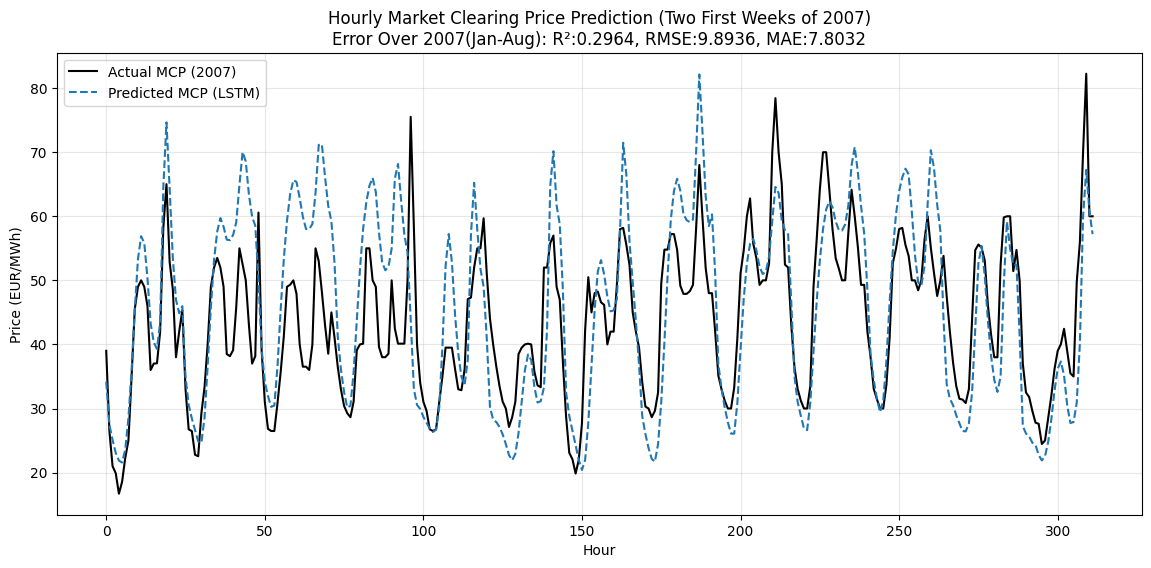

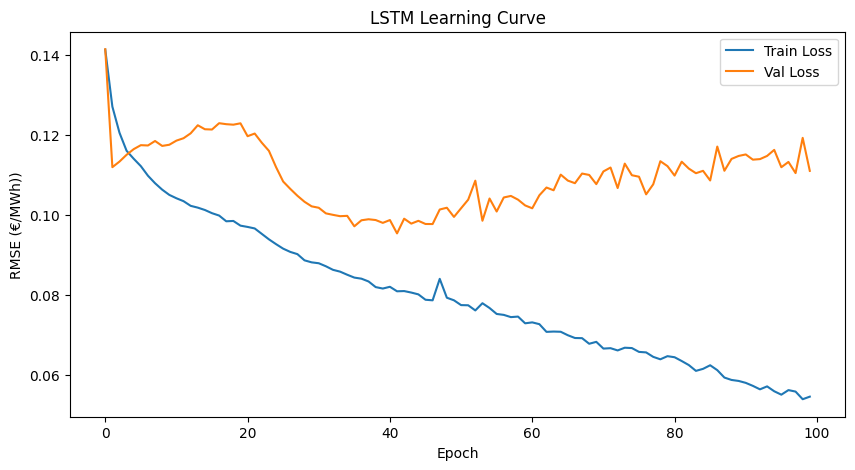

In [29]:
# Visualization: Plot the first week of 2007
plt.figure(figsize=(14, 6))
plt.plot(y_actual[:336], label='Actual MCP (2007)', color='black')
plt.plot(y_pred[:336], label='Predicted MCP (LSTM)', color='#1f77b4', linestyle='--')
plt.title(f'Hourly Market Clearing Price Prediction (Two First Weeks of 2007)\nError Over 2007(Jan-Aug): R²:{r2:.4f}, RMSE:{rmse:.4f}, MAE:{mae:.4f}')
plt.xlabel('Hour')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot Training Loss
plt.figure(figsize=(10, 5))
plt.plot(np.sqrt(np.array(history.history['loss'])), label='Train Loss')
plt.plot(np.sqrt(np.array(history.history['val_loss'])), label='Val Loss')
plt.title('LSTM Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('RMSE (€/MWh))')
plt.legend()
plt.show()

In [30]:
rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred_scaled))
mae = mean_absolute_error(y_test_seq, y_pred_scaled)
r2 = r2_score(y_test_seq, y_pred_scaled)

print(f"\n--- Test Results (2007) ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")


--- Test Results (2007) ---
RMSE: 0.0810
MAE:  0.0639
R²:   0.2964


# GRU

In [32]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# ==========================================
# 1. Load & Robust Preprocessing
# ==========================================

def load_data(file_path):
    df = pd.read_stata(file_path)
    # Filter years
    # df = df[df['year'].isin([2005, 2006, 2007])].copy()
    
    # Fill missing values (Forward fill first, then backward)
    df['ecost_int'] = df['ecost_int'].fillna(method='ffill').fillna(method='bfill')
    
    # Create datetime index
    df['hour_idx'] = df['hour'] - 1 
    df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) + pd.to_timedelta(df['hour_idx'], unit='h')
    df.set_index('date', inplace=True)
    df.sort_index(inplace=True)
    return df

data = load_data(r"Initial code\stata_data\data_regressions_passthrough.dta")

# Feature Engineering
# Cyclical encoding is crucial for LSTMs to understand "Hour 23" is close to "Hour 0"
data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

# One-hot encode day of week
dow_dummies = pd.get_dummies(data['weekd'], prefix='dow')
data = pd.concat([data, dow_dummies], axis=1)

# Feature Selection
features = [
    'coal', 'gas', 'brent', 'ecost_int', 
    'rd', 'windx', 'windx2', 'temp', 'tempx',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
] + list(dow_dummies.columns)

target = 'mg_price'

# ==========================================
# 2. Scaling (Switch to StandardScaler)
# ==========================================
# StandardScaler is robust to outliers (price spikes) unlike MinMaxScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

train_df = data.iloc[8784:23376, :]
val_df = data.iloc[23376:26304, :]
test_df = data.iloc[26304:26304+336, :]

# Fit on TRAIN only
X_train_scaled = scaler_X.fit_transform(train_df[features])
y_train_scaled = scaler_y.fit_transform(train_df[[target]])

X_test_scaled = scaler_X.transform(test_df[features])
y_test_scaled = scaler_y.transform(test_df[[target]])

X_val_scaled = scaler_X.transform(val_df[features])
y_val_scaled = scaler_y.transform(val_df[[target]])

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples: {len(test_df)}")

# # Scaling (MinMax is standard for LSTM inputs to normalize range 0-1)
# scaler_X = MinMaxScaler(feature_range=(0, 1))
# scaler_y = MinMaxScaler(feature_range=(0, 1))

# # Fit scaler ONLY on training data to avoid data leakage
# X_train_scaled = scaler_X.fit_transform(train_df[processed_features])
# y_train_scaled = scaler_y.fit_transform(train_df[[target_col]])

# X_val_scaled = scaler_X.transform(val_df[processed_features])
# y_val_scaled = scaler_y.transform(val_df[[target_col]])

# X_test_scaled = scaler_X.transform(test_df[processed_features])
# y_test_scaled = scaler_y.transform(test_df[[target_col]])

# ==========================================
# 3. Windowing
# ==========================================
WINDOW_SIZE = 24  # Look back 24 hours

def create_sequences(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)
# X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, WINDOW_SIZE)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)
x_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, WINDOW_SIZE)

# ==========================================
# 4. Improved Model Architecture
# ==========================================
model = Sequential()

# GRU Layer: Often better than LSTM for smaller/simpler time series
model.add(GRU(128, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dropout(0.3)) 

# Second GRU Layer
model.add(GRU(64, return_sequences=False))
model.add(Dropout(0.3))

# Dense Layer with Batch Normalization for stability
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())

# Output Layer
model.add(Dense(1)) 

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# ==========================================
# 5. Callbacks (The Key to High R2)
# ==========================================
callbacks = [
    # Stop if validation loss doesn't improve for 10 epochs
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    # Reduce learning rate if we get stuck
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)
]

print("Starting training with Early Stopping...")
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,  # Set high, but EarlyStopping will cut it short
    batch_size=64,
    validation_split=0.2, # Validation on the last 20% of 2005-2006 data
    shuffle=False,        # Keep time order!
    callbacks=callbacks,
    verbose=1,
    validation_data=(x_val_seq, y_val_seq)
)

Training samples: 14592
Validation samples: 2928
Testing samples: 336
Starting training with Early Stopping...
Epoch 1/100


C:\Users\julie\AppData\Local\Temp\ipykernel_66108\2962141184.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ecost_int'] = df['ecost_int'].fillna(method='ffill').fillna(method='bfill')
c:\Users\julie\anaconda3\envs\coursera\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


228/228 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 1.2588 - val_loss: 0.7539 - learning_rate: 0.0010
Epoch 2/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.7106 - val_loss: 0.8536 - learning_rate: 0.0010
Epoch 3/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.6536 - val_loss: 0.8245 - learning_rate: 0.0010
Epoch 4/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.6145 - val_loss: 0.8387 - learning_rate: 0.0010
Epoch 5/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.6021 - val_loss: 0.8487 - learning_rate: 0.0010
Epoch 6/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.5901 - val_loss: 0.7497 - learning_rate: 0.0010
Epoch 7/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.5776 - val_loss: 0.7585 - learning_rate: 0.0010
Epoch 8/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.5724 - val_loss: 0.7093 - learning_rate: 0.0010
Epoch 9/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.5659 - val_loss: 0.7621 - learning_rate: 0.0010
Epoc

In [ ]:
model.summary()

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

--- Final Results (2007 Test Set) ---
R2 Score: -0.4556
RMSE:     14.2300


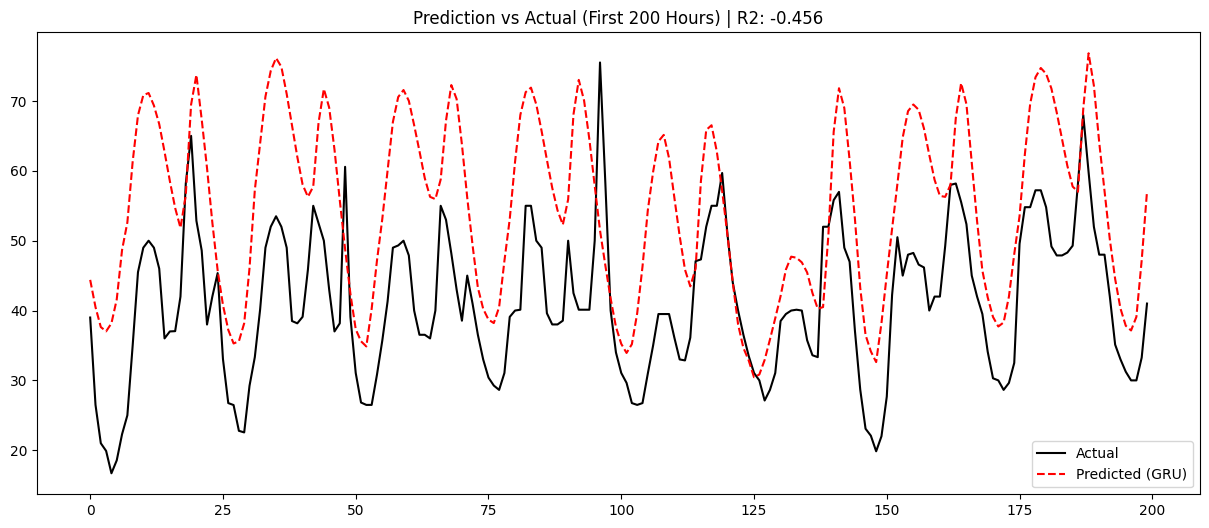

In [33]:

# ==========================================
# 6. Evaluation
# ==========================================
y_pred_scaled = model.predict(X_test_seq)

# Inverse transform to get real units
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test_seq)

# R2 Calculation
r2 = r2_score(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

print(f"\n--- Final Results (2007 Test Set) ---")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE:     {rmse:.4f}")

# Plot
plt.figure(figsize=(15, 6))
plt.plot(y_actual[:200], label='Actual', color='black', linewidth=1.5)
plt.plot(y_pred[:200], label='Predicted (GRU)', color='red', linestyle='--', linewidth=1.5)
plt.title(f'Prediction vs Actual (First 200 Hours) | R2: {r2:.3f}')
plt.legend()
plt.show()